In [13]:
import numpy as np # generic math functions
from scipy.optimize import OptimizeResult, minimize
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

In [14]:
N = 6 # number of qubits
J = 1.0 # interaction strength
PBC = True # set to false for open boundary conditions
gs = np.linspace(-2.5, 2.5, 10) #values of g to iterate over

In [ ]:
def H_tfi_qiskit(N, g=1.0, J=1.0, PBC=False):
    """Construct the Hamiltonian for the transverse field Ising model (TFIM) using Qiskit.

    Args:
        N (int): Number of qubits.
        g (float): Transverse field strength.
        J (float): Interaction strength.
        PBC (bool): If True, use periodic boundary conditions; otherwise, use open boundary conditions.
    Returns:
        SparsePauliOp: Hamiltonian operator for the TFIM."""

    if PBC:
        J_zz = [("ZZ", [n, (n+1)%N], -J) for n in range(N)]
    else:
        J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    
    g_field = [("X", [n], -g) for n in range(N)]
    
    operator_tuples = [*g_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [16]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [ ]:
### Symmetry ansatz for TFI with PBC

def get_PBC_symm_ansatz(N, ref, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        ref (list): Reference state as a list of amplitudes.
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    num_gates_per_layer = 3  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)
    symm_ansatz.initialize(ref)
    symm_ansatz.h([n for n in range(N)]) # Change to X-basis

    gate_labels = ["xx", "yy", "zz"]

    for layer in range(num_layers):
        for gate in gate_labels:

            # Apply gates in brick structure
            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n, 2*n+1)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2 +1):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n-1, (2*n)%N)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, (2*n)%N)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, (2*n)%N)
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
    return symm_ansatz

In [56]:
def cost_func(params, ansatze, hamiltonian, estimator, w):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatze (list): List of parameterized ansatz circuits with different reference states
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        w (ndarray): Array of weights for each ansatz in the cost function
    Returns:
        float: weighted sum of expectation values for each ansatz
    """
    pubs = []
    for ansatz in ansatze:
        pubs.append( (ansatz, [hamiltonian], params) )
    job = estimator.run(pubs, precision=1e-6)
    result = job.result()
    cost = 0 
    for i in range(len(result)):
        cost += w[i] * result[i].data.evs[0]
    
    
    return cost

In [ ]:
def run_ssvqe(ansatze, hamiltonian, estimator, w, num_runs=1):
    """Perform SSVQE to find the first k eigestates of the Hamiltonian, where k is the number of ansatze provided.
    Parameters:
        ansatze (list): List of parameterized ansatz circuits with different reference states
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        w (ndarray): Array of weights for each ansatz in the cost function
        num_runs (int): Number of optimization runs with different initial parameters
    Returns:
        ndarray: Optimal parameters found by VQE
    """

    num_params = ansatze[0].num_parameters
    
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1, 'tol': 1e-6}

    best_cost = np.inf
    for seed in range(num_runs):
        x0 = np.random.randn(num_params)   # near zero
        res = minimize(
            cost_func,
            x0,
            args=(ansatze, hamiltonian, estimator, w),
            method="cobyla",
            options=options,
            callback=store_intermediate_result
        )
        if res.fun < best_cost:
            best_cost = res.fun
            theta_star = res.x
        
    return theta_star


In [58]:
def store_intermediate_result(intermediate_result: OptimizeResult):
    global g
    params = intermediate_result.x # array of parameters at the intermediate iteration
    energy = intermediate_result.fun # cost function value at this iteration

    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)


In [ ]:
# Define reference states
ground_ref = np.zeros(2**N)
ground_ref[0] = 1.0  # |000...0>

first_excited_ref = np.zeros(2**N)
for i in range(N):
    first_excited_ref[2**i] = 1.0 / np.sqrt(N)  # (|100...0> + |010...0> + ... + |000...1>)/sqrt(N)


refs = [ground_ref, first_excited_ref]
ansatze = [get_PBC_symm_ansatz(N, ref, num_layers=5) for ref in refs]
k = len(refs) # number of eigenstates to approximate
w = np.arange(k, 0, -1) # weights in decreasing order, always positive
print(f"Weights assigned to each reference state: \n {w}")



Weights assigned to each reference state: 
 [2 1]


## Execute SSVQE

In [ ]:
#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []

theta_stars = []

for g in gs:
    hamiltonian = H_tfi_qiskit(N, g=g, J=J, PBC=True)
    theta_star = run_ssvqe(ansatze, hamiltonian, estimator, w, num_runs=3)
    theta_stars.append(theta_star)
    

## Postprocessing

In [61]:
eigenvalues_qiskit = np.zeros((len(gs), k))
eigenstates_qiskit = np.zeros((len(gs), k, 2**N), dtype=complex)

for i, g in enumerate(gs):
    hamiltonian = H_tfi_qiskit(N, g=g, J=J, PBC=True)
    theta_star = theta_stars[i]

    for j, ansatz in enumerate(ansatze):
        bound_circuit = ansatz.assign_parameters(theta_star, inplace=False)
        sv = Statevector(bound_circuit)
        eigenstates_qiskit[i, j, :] = sv.data

        estimator.options.default_shots = 5000
        pub = (bound_circuit, [hamiltonian])
        job = estimator.run([pub], precision=1e-6)
        result = job.result()[0]
        energy = result.data.evs[0]
        eigenvalues_qiskit[i, j] = energy


## Find eigenstates in quspin

In [62]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [ ]:
def H_tfi_quspin(N, J=1.0, g=1.0, PBC=False): 
    """Construct the Hamiltonian for the transverse field Ising model using QuSpin.
    
    Args:
        N (int): Number of qubits (spins).
        J (float): Interaction strength.
        g (float): Transverse field strength.
        PBC (bool): Whether to use periodic boundary conditions.
    Returns:
        hamiltonian: QuSpin Hamiltonian object representing the transverse field Ising model.
    """

    g_field=[[-g,i] for i in range(N)]
    
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin = [["zz", J_zz], ["x", g_field]]
    dynamic_spin = []
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [64]:
dense = True

eigenvalues_quspin = np.zeros((len(gs), k))
eigenstates_quspin = np.zeros((len(gs), k, 2**N), dtype=complex)


for i, g in enumerate(gs):
    H = H_tfi_quspin(N, J=1.0, g=g, PBC=PBC)
    if dense:
        E, V = H.as_dense_format().eigh()
    else:
        E, V = H.eigsh(k=k, which='SA')
    
    eigenvalues_quspin[i, :] = E[:k]
    for j in range(k):
        eigenstates_quspin[i, j, :] = V[:, j]





In [65]:
fractional_error = np.abs((np.array(eigenvalues_qiskit) - eigenvalues_quspin)/eigenvalues_quspin)

fidelity_arr = np.zeros((len(eigenvalues_qiskit), k))
for i in range(len(gs)):
    for j in range(k):
        overlap = np.abs(np.vdot(eigenstates_quspin[i, j], eigenstates_qiskit[i, j]))
        fidelity_arr[i, j] = overlap**2    

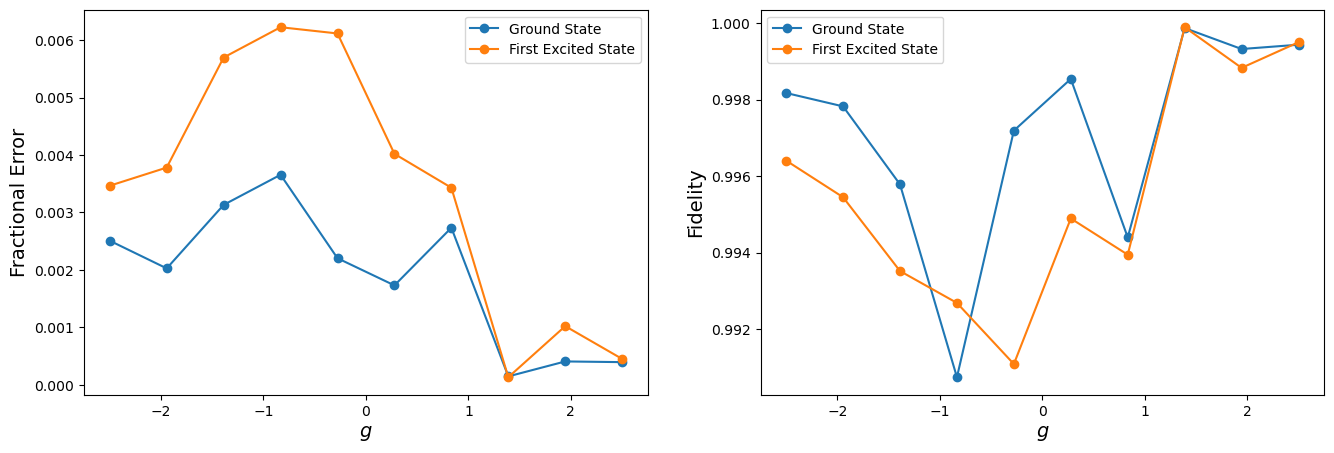

In [66]:
fig, ax = plt.subplots(1,2, figsize=(16,5))
ax[0].plot(gs, fractional_error[:,0], 'o-', label='Ground State')
ax[0].plot(gs, fractional_error[:,1], 'o-', label='First Excited State')
#ax[0].set_yscale('log')
ax[0].set_xlabel('$g$', fontsize=14)
ax[0].set_ylabel('Fractional Error', fontsize=14)
ax[0].legend()

ax[1].plot(gs, fidelity_arr[:,0], 'o-', label='Ground State')
ax[1].plot(gs, fidelity_arr[:,1], 'o-', label='First Excited State')
ax[1].set_xlabel('$g$', fontsize=14)
ax[1].set_ylabel('Fidelity', fontsize=14)
ax[1].legend()
plt.show()

In [69]:
mass_gap_qiskit = eigenvalues_qiskit[:,1] - eigenvalues_qiskit[:,0]
mass_gap_quspin = eigenvalues_quspin[:,1] - eigenvalues_quspin[:,0]  

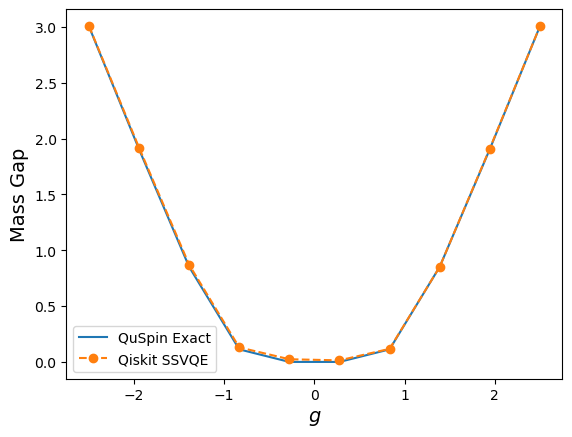

In [70]:
fig, ax = plt.subplots()
ax.plot(gs, mass_gap_quspin, label='QuSpin Exact')
ax.plot(gs, mass_gap_qiskit, 'o--', label='Qiskit SSVQE')
ax.set_xlabel('$g$', fontsize=14)
ax.set_ylabel('Mass Gap', fontsize=14)
ax.legend()
plt.show()